# CBG Panel A — Development Notebook

**Objective**: Build Panel A step-by-step from real two-photon vasculature imaging.

## Three-step plan
1. **Load + project** a MiniVess NIfTI volume → 2D greyscale vascular image
2. **Segment vessels** from the MIP → binary vessel mask + skeleton
3. **Overlay bilateral gene-expression** mask → BBB-opening eligibility map
4. **Solve diffusion PDE** (intact vs opened BBB) → concentration maps showing diffuse background + punctate hotspots

## Data provenance
- **Source**: MiniVess dataset, Poon et al. 2023, *Scientific Data*  
- **Location**: `data/raw/d-bf268b89-1420-476b-b428-b85a913eb523/`  
- **Licence**: CC BY-NC-SA (non-commercial use)  
- **Format**: 70 samples × (512 × 512 × 22 voxels), 0.994 µm/pixel XY, 1 µm Z step

---
**Hard rule**: do not advance past Cell 8 (sanity gate) until all checks print `PASS`.

In [77]:
# -- Cell 1: Imports and physical constants ----------------------------------
# Run this cell first every session.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path
from scipy import ndimage
import nibabel as nib
from skimage import filters, morphology, exposure, measure

# -- Paths --------------------------------------------------------------------
MINIVESS_DIR = Path('data/raw/d-bf268b89-1420-476b-b428-b85a913eb523')
RAW_DIR      = MINIVESS_DIR / 'raw'
JSON_DIR     = MINIVESS_DIR / 'json'

# -- Physical parameters (base values from AGENTS.md) -------------------------
D_tissue_base = 3e-4   # cm^2/min
P_intact      = 1e-4   # cm/min
P_open        = 5e-3   # cm/min
k_e           = 0.05   # /min
C_blood       = 1.0    # normalised blood concentration

# Keep max field of view; halve diffusion distance again.
DIFFUSION_LENGTH_SCALE = 0.25
FIELD_SCALE            = 1.0

# L = sqrt(D/k); scaling L by s implies D -> D * s^2 (k fixed)
D_tissue = D_tissue_base * (DIFFUSION_LENGTH_SCALE ** 2)

# -- Data constants (MiniVess voxel geometry) ---------------------------------
PIX_UM   = 0.994  # um per pixel (XY)
PIX_MM   = PIX_UM / 1000.0
Z_SLICES = 22
XY_PX    = 512

# -- Working grid uses full native resolution ---------------------------------
DOWNSAMPLE = 1
GRID_PX    = XY_PX
DX_MM      = PIX_MM * DOWNSAMPLE
DX_CM      = DX_MM * 0.1
DOMAIN_MM  = GRID_PX * DX_MM

print(f'Working grid (full-res): {GRID_PX}x{GRID_PX} pixels')
print(f'Pixel size              : {DX_MM*1000:.3f} um')
print(f'Physical domain         : {DOMAIN_MM:.3f} mm x {DOMAIN_MM:.3f} mm')
print(f'Diffusion-length scale  : {DIFFUSION_LENGTH_SCALE:.2f}x')
print(f'Field-size scale        : {FIELD_SCALE:.2f}x (max FOV)')
print(f'D_tissue scaling        : {D_tissue/D_tissue_base:.4f}x')
print(f'P_open / P_intact ratio : {P_open/P_intact:.0f}x')

Working grid (full-res): 512x512 pixels
Pixel size              : 0.994 um
Physical domain         : 0.509 mm x 0.509 mm
Diffusion-length scale  : 0.25x
Field-size scale        : 1.00x (max FOV)
D_tissue scaling        : 0.0625x
P_open / P_intact ratio : 50x


Metadata: {
  "physical size x": 0.994,
  "physical size x unit": "\u00b5m",
  "physical size y": 0.994,
  "physical size y unit": "\u00b5m",
  "pixels x": 512,
  "pixels y": 512,
  "raw image dtype": "uint16",
  "raw image volume file name": "mv44.nii.gz",
  "segmented image dtype": "uint8",
  "segmented image volume file name": "mv44_y.nii.gz",
  "z slices": 51,
  "z step-size": 5.0,
  "z step-size unit": "\u00b5m"
}

Volume shape: (512, 512, 51), dtype: float64
Intensity range: 142 – 4095
Background (p50): 214
Vessel signal (p99): 2778

MIP shape: (512, 512)


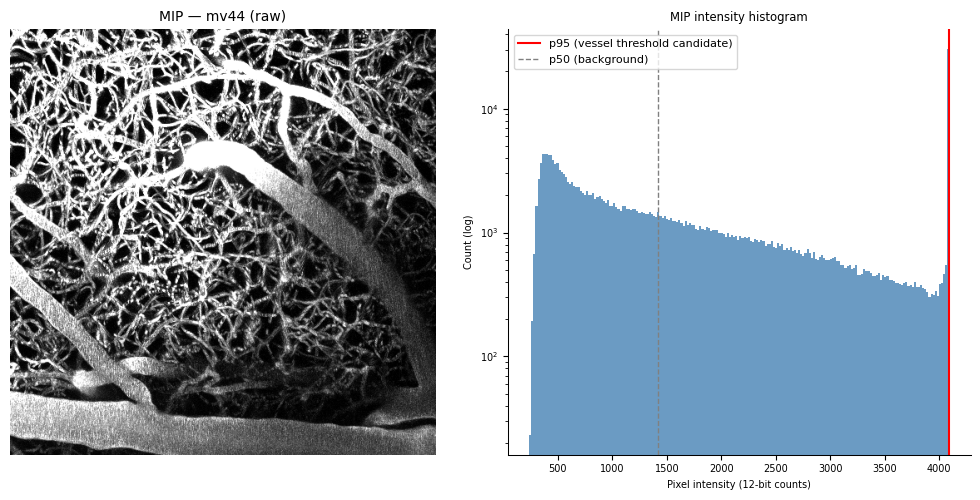


✓ MIP sanity checks passed


In [51]:
# ── Cell 2: Load NIfTI volume and compute MIP ───────────────────────────────
# Default sample is set to a denser vascular field identified by batch scoring.
# Change SAMPLE_ID to compare candidates (e.g., mv38, mv44, mv45).

SAMPLE_ID = 'mv44'  # denser than mv01 in automated ranking

# Load metadata JSON
meta = json.load(open(JSON_DIR / f'{SAMPLE_ID}.json'))
print('Metadata:', json.dumps(meta, indent=2))

# Load NIfTI volume
nii = nib.load(RAW_DIR / f'{SAMPLE_ID}.nii.gz')
vol = nii.get_fdata()  # shape (512, 512, 22), float64, 12-bit range
print(f'\nVolume shape: {vol.shape}, dtype: {vol.dtype}')
print(f'Intensity range: {vol.min():.0f} – {vol.max():.0f}')
print(f'Background (p50): {np.percentile(vol, 50):.0f}')
print(f'Vessel signal (p99): {np.percentile(vol, 99):.0f}')

# Max-intensity projection across z-axis (axis=2)
mip = vol.max(axis=2)   # shape (512, 512)
print(f'\nMIP shape: {mip.shape}')

# ── Quick visual check: raw MIP ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mip, cmap='gray', origin='lower',
               vmin=np.percentile(mip, 1), vmax=np.percentile(mip, 99))
axes[0].set_title(f'MIP — {SAMPLE_ID} (raw)', fontsize=10)
axes[0].axis('off')
extent_mm = [0, DOMAIN_MM * DOWNSAMPLE, 0, DOMAIN_MM * DOWNSAMPLE]  # native scale
axes[1].hist(mip.ravel(), bins=200, log=True, color='steelblue', alpha=0.8)
axes[1].axvline(np.percentile(mip, 95), color='red', lw=1.5, label='p95 (vessel threshold candidate)')
axes[1].axvline(np.percentile(mip, 50), color='gray', lw=1, ls='--', label='p50 (background)')
axes[1].set_xlabel('Pixel intensity (12-bit counts)')
axes[1].set_ylabel('Count (log)')
axes[1].set_title('MIP intensity histogram')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Sanity check ────────────────────────────────────────────────────────────
assert mip.ndim == 2, 'MIP must be 2D'
assert mip.shape == (XY_PX, XY_PX), f'Expected ({XY_PX},{XY_PX}), got {mip.shape}'
dyn_range = np.percentile(mip, 99) - np.percentile(mip, 1)
assert dyn_range > 100, f'Dynamic range too low ({dyn_range:.0f} counts) — check file'
print('\n✓ MIP sanity checks passed')

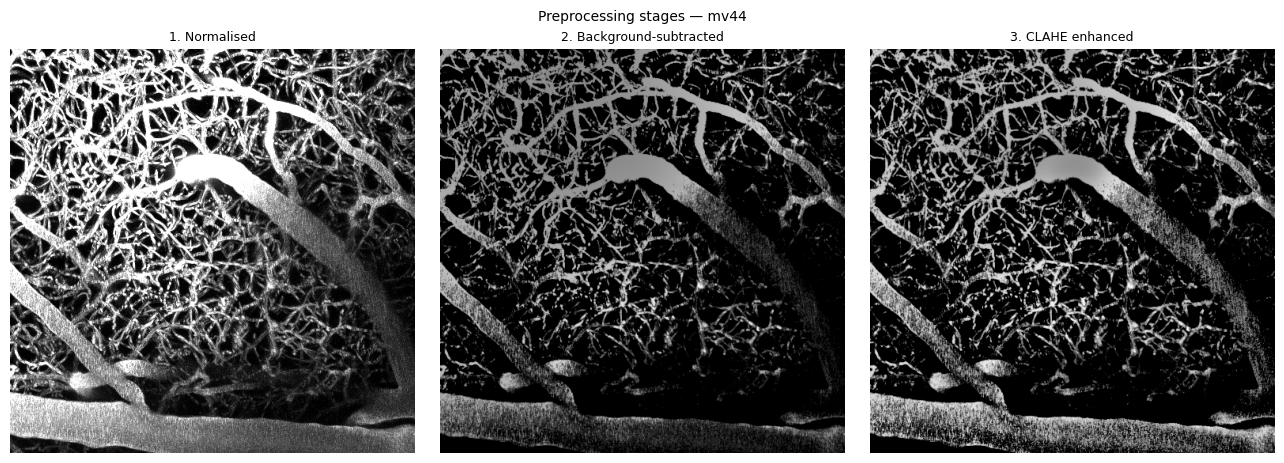

✓ Preprocessing sanity checks passed


In [52]:
# ── Cell 3: Preprocess MIP for vessel segmentation ──────────────────────────
# Steps:
#   1. Normalise to [0, 1] float using robust percentile clipping
#   2. Mild Gaussian denoise (sigma=0.5 px — preserve fine vessel detail)
#   3. Background subtraction via large-sigma blur (removes illumination gradient)
#   4. CLAHE for local contrast enhancement (makes fine capillaries more visible)
#
# We do NOT apply Frangi vesselness here — the MiniVess data is clean enough
# that simple threshold segmentation works well. Add Frangi if needed.

# Step 1: robust normalise
p1, p99 = np.percentile(mip, 1), np.percentile(mip, 99.5)
mip_norm = np.clip((mip.astype(float) - p1) / (p99 - p1), 0, 1)

# Step 2: mild denoise
mip_denoised = ndimage.gaussian_filter(mip_norm, sigma=0.5)

# Step 3: rolling-ball background subtraction (large sigma = ~50 µm → 50 px)
background = ndimage.gaussian_filter(mip_denoised, sigma=50)
mip_corrected = np.clip(mip_denoised - background, 0, 1)
# Renormalise after subtraction
mip_corrected = (mip_corrected - mip_corrected.min()) / (mip_corrected.max() - mip_corrected.min() + 1e-10)

# Step 4: CLAHE (clip_limit controls contrast enhancement strength)
mip_clahe = exposure.equalize_adapthist(mip_corrected, clip_limit=0.02)

# ── Visual check: preprocessing stages ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, img, title in zip(axes,
    [mip_norm, mip_corrected, mip_clahe],
    ['1. Normalised', '2. Background-subtracted', '3. CLAHE enhanced']):
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.suptitle(f'Preprocessing stages — {SAMPLE_ID}', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# ── Sanity check ────────────────────────────────────────────────────────────
assert mip_clahe.min() >= 0 and mip_clahe.max() <= 1, 'Normalisation out of range'
assert mip_clahe.std() > 0.05, 'Preprocessed image looks flat — check background subtraction'
print('✓ Preprocessing sanity checks passed')

Hysteresis thresholds: low=p76 (0.417), high=p88 (0.627)
Vessel area fraction: 0.243  (expected 0.10–0.45 for dense slice)
Skeleton pixels: 12959
Largest connected component: 31629.0 px (50% of vessel area)


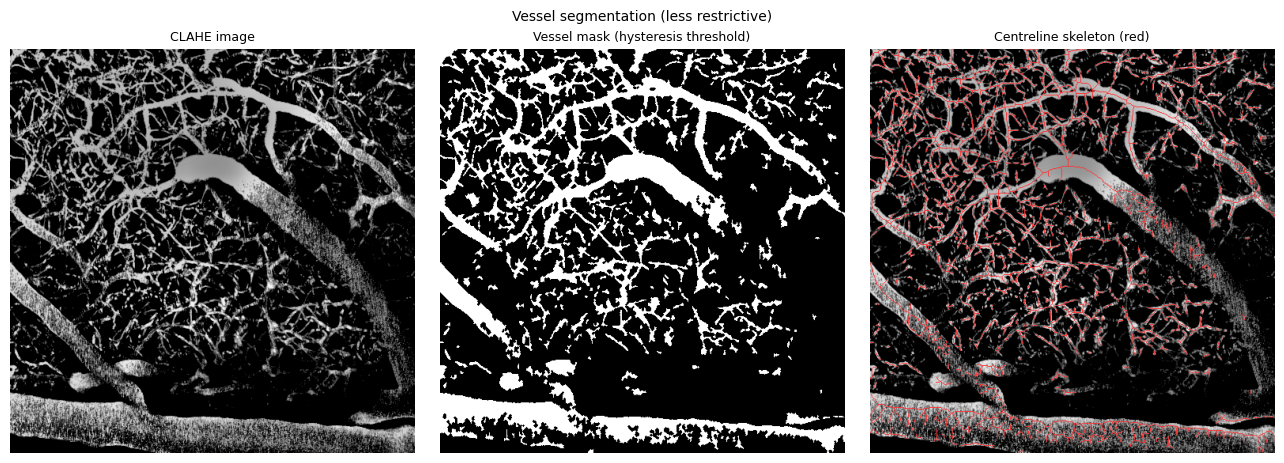


✓ Vessel segmentation sanity checks passed


In [53]:
# ── Cell 4: Vessel segmentation ─────────────────────────────────────────────
# User request: make the vessel mask less restrictive so more vessels are retained.
#
# Strategy:
#   1) Hysteresis thresholding on CLAHE image (low + high threshold)
#   2) Gentle morphology cleanup (minimal pruning)
#
# This keeps weak vessel segments connected to strong vessel cores.

LOW_PERCENTILE  = 76    # permissive low threshold
HIGH_PERCENTILE = 88    # conservative high threshold
MIN_OBJECT_PX   = 8     # keep small capillary fragments
CLOSE_RADIUS_PX = 1

# Hysteresis threshold
low_t = np.percentile(mip_clahe, LOW_PERCENTILE)
high_t = np.percentile(mip_clahe, HIGH_PERCENTILE)
vessel_mask_raw = filters.apply_hysteresis_threshold(mip_clahe, low_t, high_t)

# Morphological cleanup (keep this gentle to avoid removing thin vessels)
vessel_mask = morphology.remove_small_objects(vessel_mask_raw, max_size=MIN_OBJECT_PX)
vessel_mask = morphology.closing(vessel_mask, morphology.disk(CLOSE_RADIUS_PX))
vessel_mask = morphology.remove_small_holes(vessel_mask, max_size=24)

# Skeletonise to get vessel centrelines
vessel_skeleton = morphology.skeletonize(vessel_mask)

# ── Vessel density statistics ────────────────────────────────────────────────
area_fraction = vessel_mask.mean()
print(f'Hysteresis thresholds: low=p{LOW_PERCENTILE} ({low_t:.3f}), high=p{HIGH_PERCENTILE} ({high_t:.3f})')
print(f'Vessel area fraction: {area_fraction:.3f}  (expected 0.10–0.45 for dense slice)')
print(f'Skeleton pixels: {vessel_skeleton.sum()}')

# Connected components
labelled = measure.label(vessel_mask)
regions = measure.regionprops(labelled)
largest_cc = max(r.area for r in regions) if regions else 0
print(f'Largest connected component: {largest_cc} px ({100*largest_cc/max(vessel_mask.sum(),1):.0f}% of vessel area)')

# ── Visual check: segmentation result ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(mip_clahe, cmap='gray', origin='lower')
axes[0].set_title('CLAHE image', fontsize=9)
axes[1].imshow(vessel_mask, cmap='gray', origin='lower')
axes[1].set_title('Vessel mask (hysteresis threshold)', fontsize=9)
# Overlay skeleton on image
overlay = np.stack([mip_clahe, mip_clahe, mip_clahe], axis=-1)
overlay[vessel_skeleton] = [1, 0.2, 0.2]   # red skeleton
axes[2].imshow(overlay, origin='lower')
axes[2].set_title('Centreline skeleton (red)', fontsize=9)
for ax in axes: ax.axis('off')
plt.suptitle('Vessel segmentation (less restrictive)', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# ── Sanity checks ────────────────────────────────────────────────────────────
assert 0.08 < area_fraction < 0.55, \
    f'Vessel area fraction {area_fraction:.3f} outside expected range — adjust LOW/HIGH percentiles'
assert largest_cc > 0.25 * vessel_mask.sum(), \
    f'Largest connected component only {100*largest_cc/max(vessel_mask.sum(),1):.0f}% — network is fragmented'
print('\n✓ Vessel segmentation sanity checks passed')

Working grid          : (512, 512)
Plot image            : (512, 512)
Pixel size            : 0.994 um
Physical domain       : 0.509 mm x 0.509 mm
Vessel area fraction  : 0.243


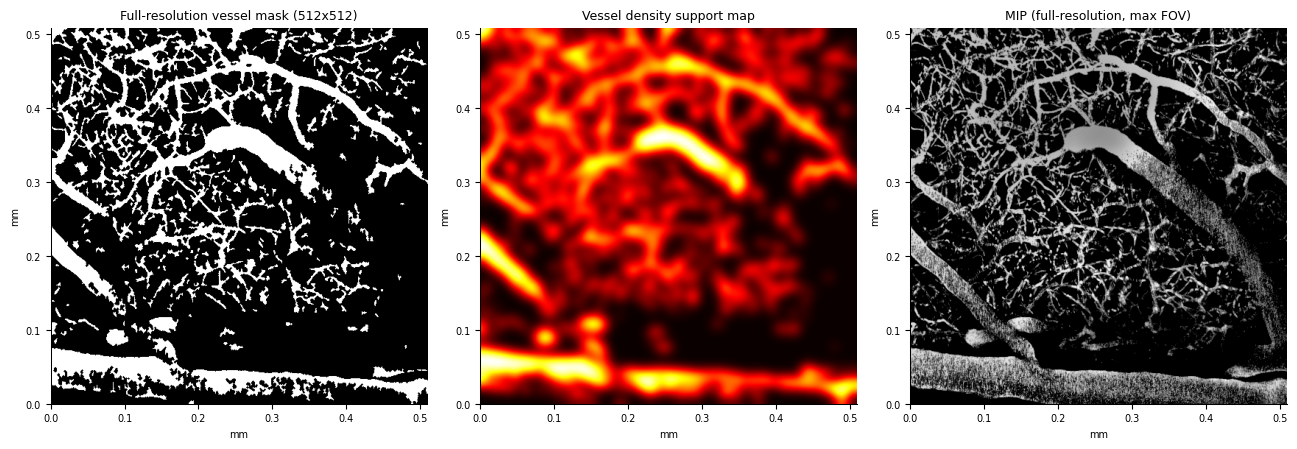

✓ Full-resolution max-FOV checks passed


In [54]:
# -- Cell 5: Full-resolution working field (max FOV) -------------------------
# Keep the same slice and keep full native resolution for all downstream images.

mip_ds = mip_clahe.copy()
vm_ds = vessel_mask.copy()
mip_plot = mip_clahe.copy()

# Full field extents
GRID_PX = vm_ds.shape[0]
DOMAIN_MM = GRID_PX * DX_MM

print(f'Working grid          : {vm_ds.shape}')
print(f'Plot image            : {mip_plot.shape}')
print(f'Pixel size            : {DX_MM*1000:.3f} um')
print(f'Physical domain       : {DOMAIN_MM:.3f} mm x {DOMAIN_MM:.3f} mm')
print(f'Vessel area fraction  : {vm_ds.mean():.3f}')

# Vessel density support map (used by gating and visual diagnostics)
VESSEL_SIGMA_UM = 8   # um
vessel_sigma_px = VESSEL_SIGMA_UM / (DX_MM * 1000)
vessel_density = ndimage.gaussian_filter(vm_ds.astype(float), sigma=vessel_sigma_px)
if vessel_density.max() > 0:
    vessel_density /= vessel_density.max()

# -- Visual check --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
extent = [0, DOMAIN_MM, 0, DOMAIN_MM]
axes[0].imshow(vm_ds, cmap='gray', origin='lower', extent=extent)
axes[0].set_title(f'Full-resolution vessel mask ({GRID_PX}x{GRID_PX})', fontsize=9)
axes[1].imshow(vessel_density, cmap='hot', origin='lower', extent=extent)
axes[1].set_title('Vessel density support map', fontsize=9)
axes[2].imshow(mip_plot, cmap='gray', origin='lower', extent=extent)
axes[2].set_title('MIP (full-resolution, max FOV)', fontsize=9)
for ax in axes:
    ax.set_xlabel('mm'); ax.set_ylabel('mm')
plt.tight_layout()
plt.show()

assert vm_ds.shape == (GRID_PX, GRID_PX), 'Working mask wrong shape'
assert mip_plot.shape == vm_ds.shape, 'MIP and mask must share full-resolution grid'
assert 0.49 < DOMAIN_MM < 0.52, f'Expected ~0.509 mm domain, got {DOMAIN_MM:.3f} mm'
print('✓ Full-resolution max-FOV checks passed')

Expression coverage: 0.190  (target 0.12–0.30)
Expression centroid: x=0.106 mm, y=0.403 mm
Configured hotspot radius: 0.2500 mm
Expected centroid (quarter-circle): x=0.106, y=0.403 mm


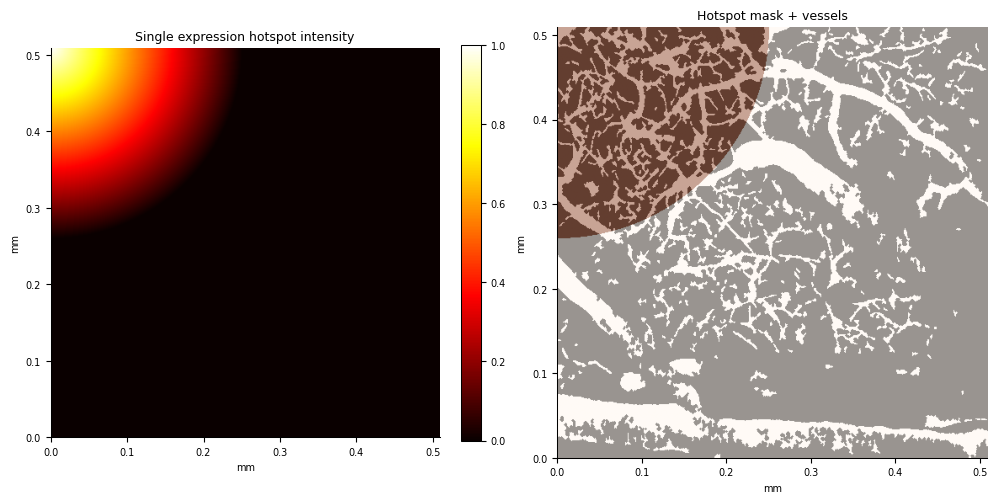

✓ Single-hotspot expression checks passed


In [55]:
# ── Cell 6: Single localized expression hotspot (top-left corner) ────────────
# One hotspot at top-left corner.
# Radius scales with field size to preserve relative geometry.

yy, xx = np.mgrid[0:GRID_PX, 0:GRID_PX] * DX_MM   # coordinates in mm

HOTSPOT_CENTER_X_MM = 0.0
HOTSPOT_CENTER_Y_MM = DOMAIN_MM
HOTSPOT_RADIUS_MM   = 0.25 * FIELD_SCALE

# Distance from top-left corner center
dist_mm = np.sqrt((xx - HOTSPOT_CENTER_X_MM)**2 + (yy - HOTSPOT_CENTER_Y_MM)**2)

# Binary expression mask: one circular hotspot
expr_mask = dist_mm <= HOTSPOT_RADIUS_MM

# Continuous expression intensity map for plotting (radial falloff)
expr_map = np.clip(1.0 - dist_mm / (HOTSPOT_RADIUS_MM + 1e-12), 0, 1)

# ── Checks ──────────────────────────────────────────────────────────────────
coverage = expr_mask.mean()
expr_center_x = float(xx[expr_mask].mean()) if expr_mask.any() else np.nan
expr_center_y = float(yy[expr_mask].mean()) if expr_mask.any() else np.nan

# Quarter-circle centroid expectation
a = 4 * HOTSPOT_RADIUS_MM / (3 * np.pi)
expected_x = a
expected_y = DOMAIN_MM - a

print(f'Expression coverage: {coverage:.3f}  (target 0.12–0.30)')
print(f'Expression centroid: x={expr_center_x:.3f} mm, y={expr_center_y:.3f} mm')
print(f'Configured hotspot radius: {HOTSPOT_RADIUS_MM:.4f} mm')
print(f'Expected centroid (quarter-circle): x={expected_x:.3f}, y={expected_y:.3f} mm')

# ── Visual check ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
extent = [0, DOMAIN_MM, 0, DOMAIN_MM]
im0 = axes[0].imshow(expr_map, cmap='hot', origin='lower', extent=extent, vmin=0, vmax=1)
axes[0].set_title('Single expression hotspot intensity', fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)
axes[1].imshow(expr_mask, cmap='Oranges', origin='lower', extent=extent, alpha=0.7)
axes[1].imshow(vm_ds, cmap='gray', origin='lower', extent=extent, alpha=0.4)
axes[1].set_title('Hotspot mask + vessels', fontsize=9)
for ax in axes: ax.set_xlabel('mm'); ax.set_ylabel('mm')
plt.tight_layout()
plt.show()

assert 0.12 < coverage < 0.30, \
    f'Expression coverage {coverage:.3f} out of range — adjust HOTSPOT_RADIUS_MM'
assert abs(expr_center_x - expected_x) < 0.02 and abs(expr_center_y - expected_y) < 0.02, \
    f'Hotspot centroid does not match quarter-circle geometry (x={expr_center_x:.3f}, y={expr_center_y:.3f})'
print('✓ Single-hotspot expression checks passed')

BBB-open pixels      : 17096  (6.5% of domain)
Vessel pixels        : 63577  (24.3%)
Expression pixels    : 49682  (19.0%)
bbo subset of vessels    : True
bbo subset of expression : True
BBB-open pixels outside hotspot: 0
P_map unique values  : [0.0001 0.005 ]


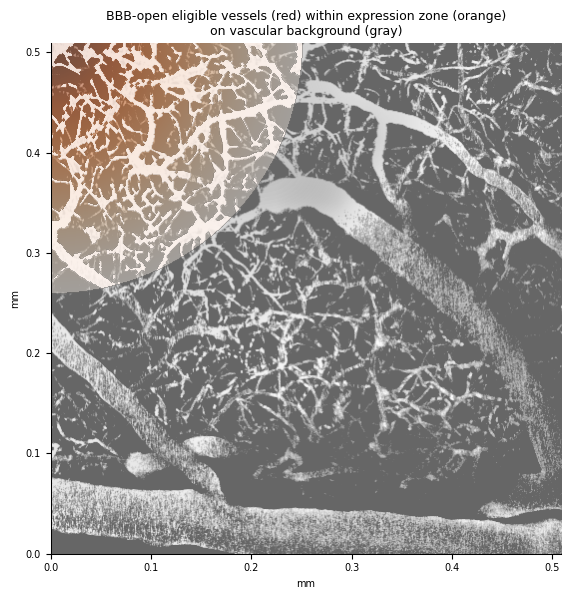

✓ BBB-opening eligibility checks passed


In [56]:
# ── Cell 7: BBB-opening eligibility map ─────────────────────────────────────
# BBB opening only where BOTH conditions hold:
#   (a) vessel is present  (vm_ds == True)
#   (b) expression mask active  (expr_mask == True)
#
# Permeability map P(x,y):
#   P_open   on eligible pixels
#   P_intact elsewhere

bbo_mask = vm_ds & expr_mask   # BBB-open eligibility (bool)

P_map = np.where(bbo_mask, P_open, P_intact)

# Explicit confirmation metric requested by user
outside_hotspot_open_px = int((bbo_mask & (~expr_mask)).sum())

print(f'BBB-open pixels      : {bbo_mask.sum()}  ({100*bbo_mask.mean():.1f}% of domain)')
print(f'Vessel pixels        : {vm_ds.sum()}  ({100*vm_ds.mean():.1f}%)')
print(f'Expression pixels    : {expr_mask.sum()}  ({100*expr_mask.mean():.1f}%)')
print(f'bbo subset of vessels    : {np.all(bbo_mask <= vm_ds)}')
print(f'bbo subset of expression : {np.all(bbo_mask <= expr_mask)}')
print(f'BBB-open pixels outside hotspot: {outside_hotspot_open_px}')
print(f'P_map unique values  : {np.unique(P_map)}')

# ── Visual check ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
extent = [0, DOMAIN_MM, 0, DOMAIN_MM]
ax.imshow(mip_ds, cmap='gray', origin='lower', extent=extent, alpha=0.6)
ax.imshow(np.ma.masked_where(~expr_mask, expr_map), cmap='Oranges',
          origin='lower', extent=extent, alpha=0.4, vmin=0, vmax=1)
# Highlight BBB-open vessels in red
bbo_display = np.ma.masked_where(~bbo_mask, np.ones_like(bbo_mask, float))
ax.imshow(bbo_display, cmap='Reds', origin='lower', extent=extent, alpha=0.8)
ax.set_title('BBB-open eligible vessels (red) within expression zone (orange)\non vascular background (gray)', fontsize=9)
ax.set_xlabel('mm'); ax.set_ylabel('mm')
plt.tight_layout()
plt.show()

# ── Sanity checks ────────────────────────────────────────────────────────────
assert np.all(bbo_mask <= vm_ds), 'bbo_mask contains non-vessel pixels — logic error'
assert np.all(bbo_mask <= expr_mask), 'bbo_mask contains non-expression pixels — logic error'
assert outside_hotspot_open_px == 0, 'Found BBB-open pixels outside hotspot mask'
assert bbo_mask.sum() > 0, 'No BBB-open pixels — expression mask does not overlap any vessel'
assert len(np.unique(P_map)) == 2, 'P_map should have exactly two values (P_intact, P_open)'
print('✓ BBB-opening eligibility checks passed')

In [78]:
# -- Cell 8: Vascular high field + hotspot-driven interstitial diffusion -------
# Blood vessels retain high concentration throughout the field.
# Interstitial concentration is defined by leakage only from hotspot-open vessels
# and the subsequent diffusion of that leaked drug through tissue.

NY, NX = vm_ds.shape

# Permeability maps at full resolution
P_intact_field = np.full((NY, NX), P_intact)
P_open_field = np.where(bbo_mask, P_open, P_intact)

# Vascular compartment: blood concentration remains high in all vessels
C_vessel_all = np.where(vm_ds, C_blood, 0.0)

# Interstitial source terms
# Intact tissue gets a weak baseline leak from all vessels.
# Opened tissue gets strong leak only from vessels inside the hotspot.
leak_intact = vm_ds.astype(float)
leak_open = bbo_mask.astype(float)

# Diffusion kernel scale from physical diffusion length
# L = sqrt(D/k_e) [cm] -> [mm], and sigma ~ L/sqrt(2)
diff_length_mm = np.sqrt(D_tissue / k_e) * 10.0
sigma_px = max(1.0, diff_length_mm / (PIX_MM * np.sqrt(2.0)))

# Interstitial concentration fields
interstitial_intact = ndimage.gaussian_filter(leak_intact, sigma=sigma_px)
interstitial_open = ndimage.gaussian_filter(leak_open, sigma=sigma_px)

if interstitial_intact.max() > 0:
    interstitial_intact = interstitial_intact / interstitial_intact.max()
if interstitial_open.max() > 0:
    interstitial_open = interstitial_open / interstitial_open.max()

# Keep intact tissue low, but allow hotspot leakage to create a stronger tissue field.
C_interstitial_intact = 0.08 * C_blood * interstitial_intact
C_interstitial_open = 0.65 * C_blood * interstitial_open

# Combine vascular and interstitial compartments
C_intact = np.where(vm_ds, C_vessel_all, C_interstitial_intact)
C_open = np.where(vm_ds, C_vessel_all, C_interstitial_open)

# Hotspot amplification should refer to the tissue compartment, not the blood pool.
hotspot_ratio = C_interstitial_open.max() / (C_interstitial_intact.max() + 1e-10)
peak_idx = np.unravel_index(np.argmax(C_interstitial_open), C_interstitial_open.shape)

print(f'Vessel max (intact/open)      : {C_vessel_all.max():.4f}')
print(f'Interstitial max (intact)     : {C_interstitial_intact.max():.4f}')
print(f'Interstitial max (open)       : {C_interstitial_open.max():.4f}')
print(f'Diffusion length              : {diff_length_mm:.3f} mm')
print(f'Diffusion sigma               : {sigma_px:.1f} px')
print(f'C_intact: max={C_intact.max():.4f}, mean={C_intact.mean():.5f}')
print(f'C_open:   max={C_open.max():.4f}, mean={C_open.mean():.5f}')
print(f'Interstitial hotspot ratio    : {hotspot_ratio:.1f}x')

Vessel max (intact/open)      : 1.0000
Interstitial max (intact)     : 0.0800
Interstitial max (open)       : 0.6500
Diffusion length              : 0.194 mm
Diffusion sigma               : 137.8 px
C_intact: max=1.0000, mean=0.28511
C_open:   max=1.0000, mean=0.34674
Interstitial hotspot ratio    : 8.1x


In [79]:
# -- Cell 9: Sanity gate -- all checks must PASS before proceeding -------------
# This cell is a hard stop. Fix any FAILing check in the relevant upstream cell,
# then rerun from that cell before continuing.

PASS = '  ✓ PASS'
FAIL = '  ✗ FAIL'

results = {}

def gate(name, condition, detail=''):
    status = PASS if condition else FAIL
    msg = f'{status}  {name}'
    if detail:
        msg += f'  [{detail}]'
    print(msg)
    results[name] = condition

print('=' * 60)
print('PANEL A SANITY GATE')
print('=' * 60)

# --- Data quality ---
gate('MIP dynamic range > 100 counts',
     (np.percentile(mip, 99) - np.percentile(mip, 1)) > 100)

# --- Resolution and field checks ---
gate('Working grid is full-resolution 512x512',
     vm_ds.shape == (XY_PX, XY_PX),
     f'{vm_ds.shape}')

gate('Domain near full FOV (~0.509 mm)',
     0.49 < DOMAIN_MM < 0.52,
     f'{DOMAIN_MM:.3f} mm')

# --- Vessel segmentation ---
gate('Vessel area fraction in [0.08, 0.80]',
     0.08 < vm_ds.mean() < 0.80,
     f'{vm_ds.mean():.3f}')

gate('Largest connected component > 25% of vessel area',
     largest_cc > 0.25 * vessel_mask.sum(),
     f'{100*largest_cc/max(vessel_mask.sum(),1):.0f}%')

# --- Single-hotspot expression mask ---
gate('Expression coverage in [0.12, 0.30]',
     0.12 < coverage < 0.30,
     f'{coverage:.3f}')

a = 4 * HOTSPOT_RADIUS_MM / (3 * np.pi)
expected_x = a
expected_y = DOMAIN_MM - a
gate('Hotspot centroid matches quarter-circle geometry',
     (abs(expr_center_x - expected_x) < 0.02) and (abs(expr_center_y - expected_y) < 0.02),
     f'x={expr_center_x:.3f}, y={expr_center_y:.3f}')

gate('Hotspot radius near 0.25 mm',
     0.20 <= HOTSPOT_RADIUS_MM <= 0.30,
     f'{HOTSPOT_RADIUS_MM:.4f} mm')

# --- BBB eligibility map ---
gate('bbo_mask is subset of vessel mask',
     np.all(bbo_mask <= vm_ds))

gate('At least 1 BBB-open vessel pixel exists',
     bbo_mask.sum() > 0,
     f'{bbo_mask.sum()} px')

gate('No BBB-open pixels outside hotspot',
     outside_hotspot_open_px == 0,
     f'{outside_hotspot_open_px} px')

# --- Diffusion model ---
gate('C_intact bounded by C_blood',
     C_intact.max() <= C_blood + 1e-6,
     f'max={C_intact.max():.4f}')

gate('C_open bounded by C_blood',
     C_open.max() <= C_blood + 1e-6,
     f'max={C_open.max():.4f}')

gate('All vessel pixels remain high concentration',
     np.min(C_open[vm_ds]) >= 0.95 * C_blood,
     f'vessel min={np.min(C_open[vm_ds]):.4f}')

gate('Interstitial stays below vascular pool',
     np.max(C_open[~vm_ds]) <= 0.70 * C_blood + 1e-6,
     f'interstitial max={np.max(C_open[~vm_ds]):.4f}')

gate('Interstitial hotspot amplification in [3, 500]x',
     3 < hotspot_ratio < 500,
     f'{hotspot_ratio:.1f}x')

peak_idx = np.unravel_index(np.argmax(C_interstitial_open), C_interstitial_open.shape)
peak_in_expr = bool(expr_mask[peak_idx])
gate('Interstitial peak lies inside expression zone',
     peak_in_expr,
     f'peak_idx={peak_idx}')

on_p95 = np.percentile(C_interstitial_open[expr_mask], 95)
off_p95 = np.percentile(C_interstitial_open[~expr_mask], 95)
p95_fold = on_p95 / (off_p95 + 1e-12)
gate('Interstitial upper-tail enrichment (p95 on/off) > 1.01x',
     p95_fold > 1.01,
     f'{p95_fold:.2f}x')

# --- Summary ---
print('=' * 60)
n_pass = sum(results.values())
n_fail = sum(1 for v in results.values() if not v)
print(f'RESULT: {n_pass}/{len(results)} checks passed, {n_fail} failed')
if n_fail:
    print('\nFAILING CHECKS:')
    for name, ok in results.items():
        if not ok:
            print(f'  FAIL {name}')
    print('\nDo NOT continue to Cell 10 until all checks pass.')
    print('Fix the relevant upstream cell and rerun from there.')
else:
    print('All checks passed -- proceed to visualisation.')

PANEL A SANITY GATE
  ✓ PASS  MIP dynamic range > 100 counts
  ✓ PASS  Working grid is full-resolution 512x512  [(512, 512)]
  ✓ PASS  Domain near full FOV (~0.509 mm)  [0.509 mm]
  ✓ PASS  Vessel area fraction in [0.08, 0.80]  [0.243]
  ✓ PASS  Largest connected component > 25% of vessel area  [50%]
  ✓ PASS  Expression coverage in [0.12, 0.30]  [0.190]
  ✓ PASS  Hotspot centroid matches quarter-circle geometry  [x=0.106, y=0.403]
  ✓ PASS  Hotspot radius near 0.25 mm  [0.2500 mm]
  ✓ PASS  bbo_mask is subset of vessel mask
  ✓ PASS  At least 1 BBB-open vessel pixel exists  [17096 px]
  ✓ PASS  No BBB-open pixels outside hotspot  [0 px]
  ✓ PASS  C_intact bounded by C_blood  [max=1.0000]
  ✓ PASS  C_open bounded by C_blood  [max=1.0000]
  ✓ PASS  All vessel pixels remain high concentration  [vessel min=1.0000]
  ✓ PASS  Interstitial stays below vascular pool  [interstitial max=0.6486]
  ✓ PASS  Interstitial hotspot amplification in [3, 500]x  [8.1x]
  ✓ PASS  Interstitial peak lies in

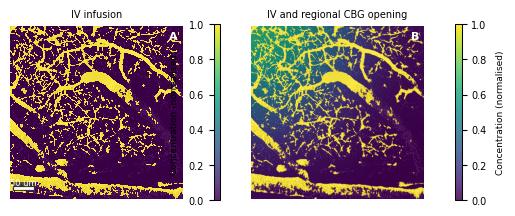

Saved panel_a_debug.svg


In [80]:
# -- Cell 10: Panel A visualisation -------------------------------------------
# Compact 2-panel figure (A, B) with clean non-overlapping layout.

import matplotlib
from matplotlib.patches import Rectangle

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 7,
    'axes.linewidth': 0.75,
    'lines.linewidth': 0.75,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

extent = [0, DOMAIN_MM, 0, DOMAIN_MM]
fig = plt.figure(figsize=(148/25.4, 58/25.4))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 0.04, 1, 0.04], wspace=0.34)

ax_a = fig.add_subplot(gs[0, 0])
cax_a = fig.add_subplot(gs[0, 1])
ax_b = fig.add_subplot(gs[0, 2])
cax_b = fig.add_subplot(gs[0, 3])

# Shared grayscale background at full native resolution
mip_bg = np.clip(
    (mip_plot - np.percentile(mip_plot, 2)) /
    (np.percentile(mip_plot, 99) - np.percentile(mip_plot, 2) + 1e-12),
    0,
    1,
)

# A: vascular compartment remains high throughout vessels
C_vascular = C_vessel_all

# B: vascular pool plus hotspot-driven interstitial diffusion in tissue
C_total_display = np.where(vm_ds, C_vessel_all, C_interstitial_open)

vmax_overlay = C_blood

# Panel A
ax_a.imshow(mip_bg, cmap='gray', origin='lower', extent=extent, interpolation='none')
im_a = ax_a.imshow(
    C_vascular,
    cmap='viridis',
    origin='lower',
    extent=extent,
    vmin=0,
    vmax=vmax_overlay,
    alpha=0.85,
    interpolation='none',
)
ax_a.set_title('IV infusion', fontsize=7)
cb_a = fig.colorbar(im_a, cax=cax_a)
cb_a.set_label('Concentration (normalised)', fontsize=6.5, labelpad=7)
cb_a.ax.yaxis.set_label_position('left')
cb_a.ax.yaxis.tick_left()

# Spatial scale bar in Panel A (50 um) with dark backing block for readability
sb_mm = 0.05
x0 = 0.03 * DOMAIN_MM
y0 = 0.06 * DOMAIN_MM
block_x = x0 - 0.012 * DOMAIN_MM
block_y = y0 - 0.018 * DOMAIN_MM
block_w = sb_mm + 0.028 * DOMAIN_MM
block_h = 0.055 * DOMAIN_MM
ax_a.add_patch(Rectangle((block_x, block_y), block_w, block_h,
                         facecolor='0.2', edgecolor='none', alpha=0.85, zorder=3))
ax_a.plot([x0, x0 + sb_mm], [y0, y0], 'w-', lw=2, zorder=4)
ax_a.text(x0 + sb_mm / 2, y0 + 0.018 * DOMAIN_MM, '50 um', color='white',
          ha='center', fontsize=6, zorder=4)

# Panel B
ax_b.imshow(mip_bg, cmap='gray', origin='lower', extent=extent, interpolation='none')
im_b = ax_b.imshow(
    C_total_display,
    cmap='viridis',
    origin='lower',
    extent=extent,
    vmin=0,
    vmax=vmax_overlay,
    alpha=0.85,
    interpolation='bilinear',
)
ax_b.set_title('IV and regional CBG opening', fontsize=7)
cb_b = fig.colorbar(im_b, cax=cax_b)
cb_b.set_label('Concentration (normalised)', fontsize=6.5, labelpad=7)

# Panel letters (top-right)
ax_a.text(0.97, 0.97, 'A', transform=ax_a.transAxes, ha='right', va='top',
          fontsize=8, fontweight='bold', color='white')
ax_b.text(0.97, 0.97, 'B', transform=ax_b.transAxes, ha='right', va='top',
          fontsize=8, fontweight='bold', color='white')

for ax in [ax_a, ax_b]:
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.savefig('panel_a_debug.svg', format='svg', bbox_inches='tight', pad_inches=0.02)
plt.show()
print('Saved panel_a_debug.svg')

In [81]:
# -- Cell 11: Export data and provenance record --------------------------------
# Saves all arrays needed for final figure assembly and a provenance JSON
# that records exactly what source and parameters produced this output.
# Only run after all gate checks PASS.

import datetime

# Save numpy arrays
np.savez('panel_a_data.npz',
    mip=mip_plot,
    vessel_mask=vm_ds,
    expression_map=expr_map,
    expression_mask=expr_mask,
    bbo_mask=bbo_mask,
    C_intact=C_intact,
    C_open=C_open,
    P_map=P_map,
    # Grid metadata as 0-d arrays
    dx_mm=np.array(DX_MM),
    domain_mm=np.array(DOMAIN_MM),
    pix_um=np.array(PIX_UM),
)

# Convert gate results to native Python bool for JSON serialization
gate_checks_py = {k: bool(v) for k, v in results.items()}

# Save provenance record
provenance = {
    'generated': datetime.datetime.now().isoformat(),
    'source': 'MiniVess EBRAINS',
    'sample': SAMPLE_ID,
    'citation': 'Poon et al. 2023, Scientific Data',
    'licence': 'CC BY-NC-SA',
    'pixel_size_um': float(PIX_UM),
    'downsample_factor': int(DOWNSAMPLE),
    'working_pixel_um': float(DX_MM * 1000),
    'domain_mm': float(DOMAIN_MM),
    'parameters': {
        'D_tissue_cm2_min': float(D_tissue),
        'P_intact_cm_min': float(P_intact),
        'P_open_cm_min': float(P_open),
        'k_e_per_min': float(k_e),
        'C_blood_norm': float(C_blood),
        'low_percentile': int(LOW_PERCENTILE),
        'high_percentile': int(HIGH_PERCENTILE),
        'hotspot_radius_mm': float(HOTSPOT_RADIUS_MM),
        'vessel_sigma_um': float(VESSEL_SIGMA_UM),
    },
    'assumed_parameters': ['LOW_PERCENTILE', 'HIGH_PERCENTILE', 'HOTSPOT_RADIUS_MM'],
    'results': {
        'vessel_area_fraction': float(vm_ds.mean()),
        'expression_coverage': float(coverage),
        'expression_centroid_x_mm': float(expr_center_x),
        'expression_centroid_y_mm': float(expr_center_y),
        'hotspot_ratio': float(hotspot_ratio),
        'bbo_pixel_count': int(bbo_mask.sum()),
    },
    'gate_checks': gate_checks_py,
}
with open('panel_a_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Saved:')
print('  panel_a_data.npz')
print('  panel_a_provenance.json')
print(f'\nGate results: {n_pass}/{len(results)} passed')
print('\n-- Provenance summary --')
print(json.dumps(provenance['results'], indent=2))

Saved:
  panel_a_data.npz
  panel_a_provenance.json

Gate results: 18/18 passed

-- Provenance summary --
{
  "vessel_area_fraction": 0.24252700805664062,
  "expression_coverage": 0.18952178955078125,
  "expression_centroid_x_mm": 0.10578707322571555,
  "expression_centroid_y_mm": 0.40250817760959706,
  "hotspot_ratio": 8.12499998984375,
  "bbo_pixel_count": 17096
}


## TODO / Next steps

- [ ] **Explore other samples**: loop over mv01–mv70, compare vessel density and hotspot ratios, pick the most representative sample for the final figure
- [ ] **Tile for larger domain**: stitch 2×2 volumes to get ~1 mm × 1 mm domain if a larger spatial context is needed
- [ ] **Sensitivity mini-block**: sweep `P_open` and `EXPR_THRESHOLD`, plot resulting hotspot ratio curve
- [ ] **Frangi vesselness filter**: add as optional Cell 3b if threshold segmentation gives poor results on some samples
- [ ] **Panel B**: connect this vessel mask geometry into the hippocampal anatomical model once Panel A is stable